# Spectral Energy Distribution (SED) Plotter
Reads ECSV SED files (comma- or space-separated) and plots detections vs. upper limits.
Multiple instruments and/or energy ranges are automatically assigned distinct colours and markers.

In [50]:
import re
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [79]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Change here to your path and file
path_user = "/Users/stefano/Documenti/work/CTAO/project_Doro/git_repository/"
path_git = "magic_dl5_dataportal/ecsv/"
path_project = "2026a_NToO/" #   2022e_maxiJ1820
ecsv_name = "Fig7/IC171106A_fig7a_SED_NToO_DataRelease.ecsv"
ECSV_FILE = path_user+path_git+path_project+ecsv_name
ECSV_FILE = "../magic_2025a_fig5_sed_A.ecsv"
ECSV_FILE = "../magic_2025a_fig5_sed_B.ecsv"
ECSV_FILE = "../magic_2025a_fig5_sed_C.ecsv"
ECSV_FILE = "../magic_2025a_fig5_sed_D.ecsv"
# ───────────────────────────────────────────────────────────────────────────────

In [80]:
# ── Utilities ──────────────────────────────────────────────────────────────────

def detect_delimiter(filepath):
    """Return the delimiter declared in the ECSV header, or ' ' if absent."""
    with open(filepath, "r") as fh:
        for line in fh:
            if not line.startswith("#"):
                break
            m = re.search(r"delimiter:\s*['\"]?(.)['\"]", line)
            if m:
                return m.group(1)
    return " "


def load_ecsv(filepath):
    """Load an ECSV file regardless of delimiter and return an Astropy Table."""
    delim = detect_delimiter(filepath)
    return Table.read(filepath, format="ascii.ecsv", delimiter=delim)


def is_upper_limit(dataformat_value):
    """True when the dataformat cell flags an upper limit (UL or 'upper limit …')."""
    if dataformat_value is None:
        return False
    val = str(dataformat_value)
    return bool(
        re.search(r"upper\s+limit", val, re.IGNORECASE)
        or re.search(r"\bUL\b", val, re.IGNORECASE)
    )


def col_float(table, name, mask):
    """Return a float numpy array for column *name* filtered by *mask*."""
    return np.array(table[name][mask], dtype=float)


def _unit_str(table, col):
    """Return the unit string of a column, or '' if absent/null."""
    try:
        u = str(table[col].unit)
        return u if u not in ("", "None", "nan") else ""
    except Exception:
        return ""


def norm_val(val):
    """Normalise a value to float; return np.nan if missing/null."""
    try:
        f = float(val)
        return f if np.isfinite(f) else np.nan
    except (TypeError, ValueError):
        return np.nan


def make_group_label(instrument, single_group):
    """Legend label: just the instrument name (groups here are per-instrument)."""
    return str(instrument)

In [81]:
# ── Load data ──────────────────────────────────────────────────────────────────
tbl = load_ecsv(ECSV_FILE)
print(f"Loaded {len(tbl)} rows  |  columns: {tbl.colnames}")
tbl[:5]

Loaded 9 rows  |  columns: ['srcname', 'en', 'en_wlo', 'en_wup', 'nufnu', 'nufnu_elo', 'nufnu_eup', 'tstart', 'tstop', 'texpo', 'instrument', 'dataformat', 'comments']


srcname,en,en_wlo,en_wup,nufnu,nufnu_elo,nufnu_eup,tstart,tstop,texpo,instrument,dataformat,comments
latex,TeV,TeV,TeV,erg / (s cm2),erg / (s cm2),erg / (s cm2),mjd,mjd,h,latex,latex,latex
str12,float32,float32,float32,float32,float32,float32,float32,float32,float32,str5,str1,str7
RGB 0521+211,0.10306515,nan,nan,1.8401398e-10,3.9446984e-11,3.9446984e-11,58908.85,58908.85,0.72,MAGIC,--,State D
RGB 0521+211,0.13822068,nan,nan,3.1054462e-10,3.302159e-11,3.302159e-11,58908.85,58908.85,0.72,MAGIC,--,State D
RGB 0521+211,0.18778263,nan,nan,3.0243352e-10,3.152529e-11,3.152529e-11,58908.85,58908.85,0.72,MAGIC,--,State D
RGB 0521+211,0.25413647,nan,nan,3.0001146e-10,3.424561e-11,3.424561e-11,58908.85,58908.85,0.72,MAGIC,--,State D
RGB 0521+211,0.33513546,nan,nan,2.3155607e-10,3.6266636e-11,3.6266636e-11,58908.85,58908.85,0.72,MAGIC,--,State D


In [82]:
# ── Global metadata ────────────────────────────────────────────────────────────
meta = tbl.meta
source_name = (
    meta.get("Source")
    or (str(tbl["srcname"][0]) if "srcname" in tbl.colnames else "Unknown source")
)

en_unit    = _unit_str(tbl, "en")
nufnu_unit = _unit_str(tbl, "nufnu")

# Optional: time range label from tstart/tstop metadata (if present)
time_label = meta.get("Comments", "")

print(f"Source     : {source_name}")
print(f"Energy unit: {en_unit}")
print(f"Flux unit  : {nufnu_unit}")

Source     : VER 0521+211
Energy unit: TeV
Flux unit  : erg / (s cm2)


In [83]:
# ── Build dataset groups ───────────────────────────────────────────────────────
# For SEDs, group by instrument only.
# Unlike the light curve, energy (en) is the x-axis, not a grouping criterion.

instruments_col = [str(v) for v in tbl["instrument"]]

# Preserve insertion order
groups = list(dict.fromkeys(instruments_col))   # unique instruments in file order
single_group = len(groups) == 1

print(f"Found {len(groups)} instrument group(s): {groups}")

Found 1 instrument group(s): ['MAGIC']


In [84]:
# ── Visual style palette ───────────────────────────────────────────────────────
COLORS = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#17becf",  # cyan
    "#bcbd22",  # yellow-green
    "#ff7f0e",  # orange
]
DET_MARKERS = ["o", "s", "^", "D", "P", "X", "*", "h", "+"]


def style_for(group_index):
    idx = group_index % len(COLORS)
    return COLORS[idx], DET_MARKERS[idx % len(DET_MARKERS)]

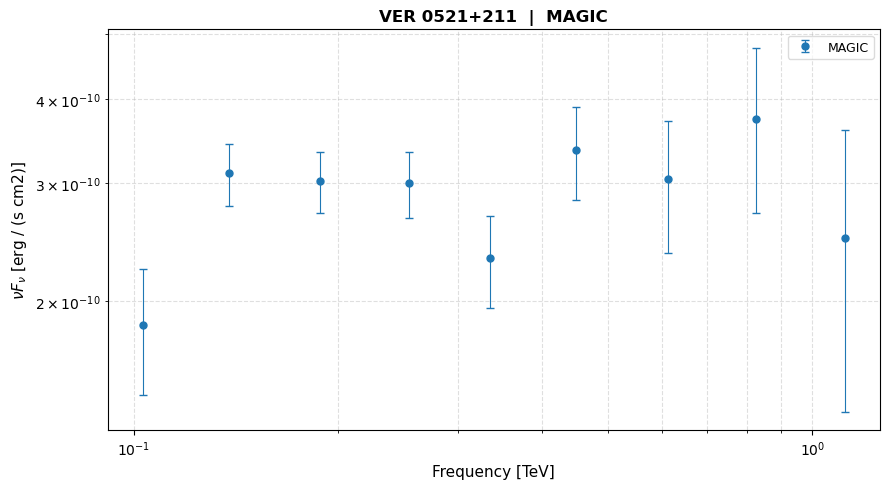

In [85]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ul_mask_global = np.array([is_upper_limit(v) for v in tbl["dataformat"]])

for g_idx, instr in enumerate(groups):
    color, det_mk = style_for(g_idx)

    group_mask = np.array([v == instr for v in instruments_col])
    det_mask   = group_mask & ~ul_mask_global
    ul_mask    = group_mask &  ul_mask_global

    label_base = make_group_label(instr, single_group)

    # ── Detections ────────────────────────────────────────────────────────────
    if det_mask.any():
        en      = col_float(tbl, "en",        det_mask)
        en_wlo  = col_float(tbl, "en_wlo",    det_mask)
        en_wup  = col_float(tbl, "en_wup",    det_mask)
        nufnu   = col_float(tbl, "nufnu",     det_mask)
# This works when the flux_elo and flux_eup values are the lower and upper boundaries, rather than the errors
#        elo     = np.abs(nufnu - col_float(tbl, "nufnu_elo", det_mask))
#        eup     = np.abs(col_float(tbl, "nufnu_eup", det_mask) - nufnu)
# This works when the flux_elo and flux_eup values are the errors
        elo = np.abs(col_float(tbl, "nufnu_elo", det_mask))
        eup = np.abs(col_float(tbl, "nufnu_eup", det_mask))

        # x error bars only when bin widths are non-zero
        xerr = None
        if np.any(en_wlo > 0) or np.any(en_wup > 0):
            xerr = [en_wlo, en_wup]

        ax.errorbar(
            en, nufnu,
            yerr=[elo, eup],
            xerr=xerr,
            fmt=det_mk,
            color=color,
            markersize=5,
            linewidth=0.8,
            capsize=3,
            label=label_base,
            zorder=3,
        )

    # ── Upper limits ──────────────────────────────────────────────────────────
    if ul_mask.any():
        en_ul    = col_float(tbl, "en",    ul_mask)
        nufnu_ul = col_float(tbl, "nufnu", ul_mask)

        ax.errorbar(
            en_ul, nufnu_ul,
            yerr=0.15 * nufnu_ul,   # cosmetic arrow length
            fmt="v",
            color=color,
            markersize=8,
            linewidth=0,
            capsize=0,
            uplims=True,
            label=f"{label_base} (UL)",
            zorder=3,
        )

# ── Axes cosmetics ─────────────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(f"Frequency [{en_unit}]" if en_unit else "Frequency", fontsize=11)
ax.set_ylabel(
    f"$\\nu F_{{\\nu}}$ [{nufnu_unit}]" if nufnu_unit else r"$\nu F_{\nu}$",
    fontsize=11,
)

all_instruments = ", ".join(groups)
ax.set_title(
    f"{source_name}  |  {all_instruments}",
    fontsize=12, fontweight="bold",
)

ax.legend(fontsize=9, framealpha=0.7)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
# Uncomment the following lines to save the figure as a png
#plt.savefig("sed.png", dpi=150, bbox_inches="tight")
#print("Figure saved as sed.png")